In [248]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [249]:
df =pd.read_csv(r"C:\Users\DELL\Downloads\Food_Delivery_Times.csv")

In [250]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [251]:
df.shape

(1000, 9)

In [252]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [253]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [254]:
df.duplicated().sum()

0

In [255]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [256]:
cols =['Weather','Traffic_Level','Time_of_Day']

for col in cols: 
    df[col]=df[col].fillna(df[col].mode()[0])

In [257]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                    0
Traffic_Level              0
Time_of_Day                0
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

<Axes: xlabel='Courier_Experience_yrs', ylabel='Count'>

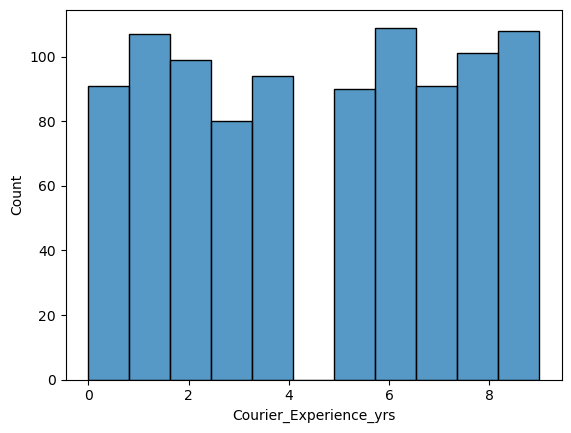

In [258]:
sns.histplot(df['Courier_Experience_yrs'])

In [259]:
df['Courier_Experience_yrs']=df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

In [260]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [261]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 1000 non-null   object 
 3   Traffic_Level           1000 non-null   object 
 4   Time_of_Day             1000 non-null   object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  1000 non-null   float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


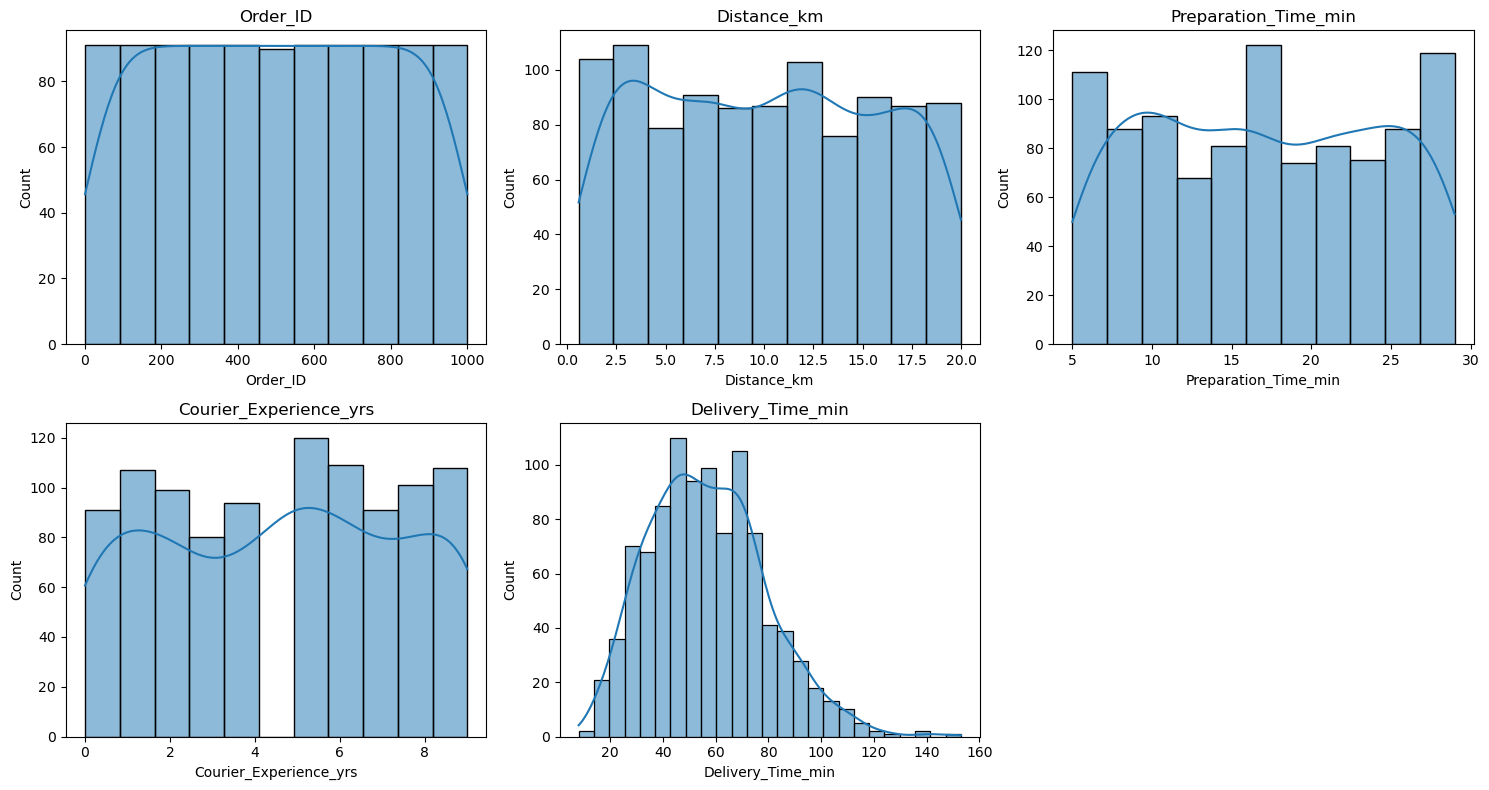

In [262]:
num_col = [
'Order_ID',
'Distance_km',
'Preparation_Time_min',
'Courier_Experience_yrs',
'Delivery_Time_min'
] 

plt.figure(figsize=(15,8))

for i, col in enumerate(num_col, 1):
    plt.subplot(2,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

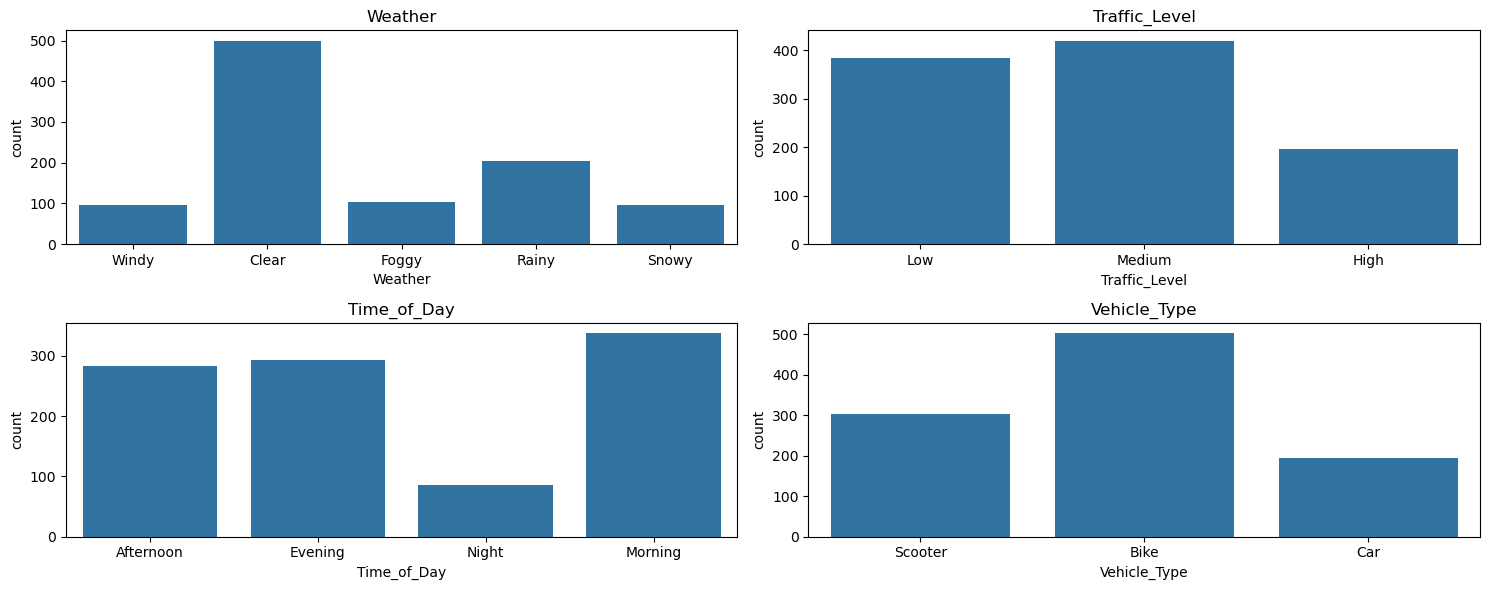

In [263]:
cat_col = [
'Weather',
'Traffic_Level',
'Time_of_Day',
'Vehicle_Type'
]

plt.figure(figsize=(15,6))

for i, col in enumerate(cat_col, 1):
    plt.subplot(2,2,i)
    sns.countplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [264]:
import pandas as pd

target = 'Delivery_Time_min'

num_col = [
'Distance_km',
'Preparation_Time_min',
'Courier_Experience_yrs'
]

num_results = []

for col in num_col:
    
    corr = df[col].corr(df[target])
    
    decision = "Keep" if abs(corr) >= 0.5 else "Drop"
    
    num_results.append({
        "Feature": col,
        "Correlation": corr,
        "Decision": decision
    })

anova_results_num = pd.DataFrame(num_results)

print(anova_results_num)

                  Feature  Correlation Decision
0             Distance_km     0.780998     Keep
1    Preparation_Time_min     0.307350     Drop
2  Courier_Experience_yrs    -0.089111     Drop


In [265]:
from scipy.stats import f_oneway

cat_col = [
'Weather',
'Traffic_Level',
'Time_of_Day',
'Vehicle_Type'
]

cat_results = []

for col in cat_col:
    
    groups = [df[df[col] == cat][target] for cat in df[col].unique()]
    
    f_stat, p_value = f_oneway(*groups)
    
    decision = "Keep" if p_value < 0.05 else "Drop"
    
    cat_results.append({
        "Feature": col,
        "P-value": p_value,
        "Decision": decision
    })

anova_results_cat = pd.DataFrame(cat_results)

print(anova_results_cat)

         Feature       P-value Decision
0        Weather  2.472288e-08     Keep
1  Traffic_Level  3.869707e-09     Keep
2    Time_of_Day  7.915077e-01     Drop
3   Vehicle_Type  5.548673e-01     Drop


In [266]:
num_keep = anova_results_num[anova_results_num['Decision'] == 'Keep']['Feature'].tolist()

cat_keep = anova_results_cat[anova_results_cat['Decision'] == 'Keep']['Feature'].tolist()

selected_features = num_keep + cat_keep

selected_features.append('Delivery_Time_min')

selected_features.append('Preparation_Time_min')

selected_features.append('Time_of_Day')
df_selected = df[selected_features]

print("Selected Features:", selected_features)

Selected Features: ['Distance_km', 'Weather', 'Traffic_Level', 'Delivery_Time_min', 'Preparation_Time_min', 'Time_of_Day']


In [267]:
df_selected.head()

,Distance_km,Weather,Traffic_Level,Delivery_Time_min,Preparation_Time_min,Time_of_Day
0,7.93,Windy,Low,43,12,Afternoon
1,16.42,Clear,Medium,84,20,Evening
2,9.52,Foggy,Low,59,28,Night
3,7.44,Rainy,Medium,37,5,Afternoon
4,19.03,Clear,Low,68,16,Morning


In [268]:
cat_col =['Weather','Traffic_Level','Time_of_Day']
df_selected =pd.get_dummies(df_selected,columns=cat_col,drop_first=True)

In [269]:
df_selected.head()

,Distance_km,Delivery_Time_min,Preparation_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night
0,7.93,43,12,False,False,False,True,True,False,False,False,False
1,16.42,84,20,False,False,False,False,False,True,True,False,False
2,9.52,59,28,True,False,False,False,True,False,False,False,True
3,7.44,37,5,False,True,False,False,False,True,False,False,False
4,19.03,68,16,False,False,False,False,True,False,False,True,False


In [270]:
df_selected =df_selected.astype(int)

In [271]:
df_selected.head()

,Distance_km,Delivery_Time_min,Preparation_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night
0,7,43,12,0,0,0,1,1,0,0,0,0
1,16,84,20,0,0,0,0,0,1,1,0,0
2,9,59,28,1,0,0,0,1,0,0,0,1
3,7,37,5,0,1,0,0,0,1,0,0,0
4,19,68,16,0,0,0,0,1,0,0,1,0


In [272]:
from sklearn.preprocessing import StandardScaler

In [273]:
scaler =StandardScaler() 
col =['Distance_km','Preparation_Time_min']
df_selected[col] =scaler.fit_transform(df_selected[col])

In [274]:
df_selected.head()

,Distance_km,Delivery_Time_min,Preparation_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night
0,-0.450965,43,-0.691853,0,0,0,1,1,0,0,0,0
1,1.125836,84,0.419111,0,0,0,0,0,1,1,0,0
2,-0.100565,59,1.530076,1,0,0,0,1,0,0,0,1
3,-0.450965,37,-1.663947,0,1,0,0,0,1,0,0,0
4,1.651436,68,-0.136371,0,0,0,0,1,0,0,1,0


In [275]:
from sklearn.model_selection import train_test_split

In [276]:
X =df_selected.drop('Delivery_Time_min',axis=1)
y =df_selected['Delivery_Time_min']

In [277]:
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [278]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [279]:
df_selected.columns

Index(['Distance_km', 'Delivery_Time_min', 'Preparation_Time_min',
       'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy',
       'Traffic_Level_Low', 'Traffic_Level_Medium', 'Time_of_Day_Evening',
       'Time_of_Day_Morning', 'Time_of_Day_Night'],
      dtype='object')

In [280]:
from sklearn.linear_model import LinearRegression

In [281]:
model =LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [282]:
y_pred = model.predict(X_test)

In [283]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Adjusted R2
n = X_test.shape[0]   # number of observations
p = X_test.shape[1]   # number of features

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)
print("Adjusted R2 Score:", adjusted_r2)

Mean Absolute Error: 6.288836126114591
Mean Squared Error: 83.24020353957451
Root Mean Squared Error: 9.123606936928756
R2 Score: 0.8142900624408549
Adjusted R2 Score: 0.8034240554560113


In [322]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [324]:
from sklearn.metrics import r2_score

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.7525214973040849
Test R2: 0.8142900624408549


In [326]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train Ridge Model
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

# Prediction
y_pred_ridge = ridge.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ridge)

print("Ridge MSE:", mse)
print("Ridge RMSE:", rmse)
print("Ridge R2:", r2)

Ridge MSE: 83.5227177380163
Ridge RMSE: 9.139076416028935
Ridge R2: 0.8136597697226583


In [328]:
train_pred = ridge.predict(X_train)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, y_pred_ridge)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.7525088667913357
Test R2: 0.8136597697226583


In [330]:
linear = LinearRegression()
linear.fit(X_train,y_train)

y_pred_linear = linear.predict(X_test)

print("Linear R2:", r2_score(y_test,y_pred_linear))
print("Ridge R2:", r2_score(y_test,y_pred_ridge))

Linear R2: 0.8142900624408549
Ridge R2: 0.8136597697226583


Data Collection
↓
Data Cleaning
↓
EDA
↓
Feature Selection
↓
Encoding
↓
Scaling
↓
Train/Test Split
↓
Model Training
    • Linear
    • Ridge
    • Lasso
    • Polynomial
↓
Model Evaluation
↓
Overfitting Check
↓
Visualization

In [335]:
from sklearn.preprocessing import PolynomialFeatures


In [337]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)

# Transform features
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train model
model_poly = LinearRegression()

model_poly.fit(X_train_poly, y_train)

# Prediction
y_pred_poly = model_poly.predict(X_test_poly)

In [339]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred_poly)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print("Polynomial R2:", r2)
print("Polynomial RMSE:", rmse)

Polynomial R2: 0.8102256026320132
Polynomial RMSE: 9.222906486824028
